<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/03_Notion_Review_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review Preprocessing & Stopwords**

## **⚙️ Process Description**


The preprocessing stage is conducted to transform raw user reviews from the Notion application into clean, structured, and analyzable text data. Raw text often contains inconsistencies, noise, and irrelevant elements that may reduce the accuracy of further analysis such as sentiment classification or text mining.

The preprocessing pipeline consists of several sequential steps:

| Step | Task | Description | Tool / Method |
|------|------|------------|---------------|
| 1 | Data Cleaning | Removed missing, empty, and inconsistent data to ensure dataset quality and reliability. | pandas |
| 2 | Remove Duplicates | Eliminated duplicate review entries to avoid bias in analysis. | pandas |
| 3 | Case Folding | Converted all text into lowercase to standardize word representation. | str.lower() |
| 4 | Slang Normalization  | Replaced informal or abbreviated words with their standard forms to improve text clarity. | custom dictionary |
| 5 | Noise Removal | Removed URLs, numbers, punctuation, symbols, and excessive whitespace to reduce noise. | re, string |
| 6 | Tokenization | Split sentences into individual words (tokens) for detailed text processing. | NLTK word_tokenize |
| 7 | Stopword Removal | Filtered out common English words with low semantic value. | NLTK stopwords |
| 8 | Stemming | Reduced words to their root form to maintain consistency in analysis. | NLTK PorterStemmer |
| 9 | Frequent Words Analysis  | Identified the most common words to understand dominant terms in the dataset. | Counter |
| 10 | Rare Words Removal | Removed infrequent words that may introduce noise in the analysis. | frequency threshold |
| 11 | Text Reconstruction | Rejoined processed tokens into clean text for further analysis. | join() |
| 12 | Data Export | Saved the cleaned dataset for subsequent analysis or modeling. | pandas |

### **Setup & Data Loading**

In [25]:
!pip install emoji
import pandas as pd
import re
import string
import nltk
import emoji
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
#Load dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Tugas Individu/Dataset/review_notion_raw.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,acfbcf53-ca8a-40b3-a92e-d94447da864f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"had a payment issue, the SAV solved it quickly.",5,0,NaN,2026-04-29 16:35:03,NaN,NaN,NaN
1,ae9206ec-742a-417e-a83a-7c5536ec50f5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,NaN,NaN,0.6.3809
2,9f587909-e254-4d20-a2f1-440cd989727d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I loved this app, but my documents keep going ...",3,0,NaN,2026-04-29 10:38:49,NaN,NaN,NaN
3,ab75d7d3-340f-40a9-aa88-23bed04f99a7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,powerful (All in 1). but new ke liye itna jada...,1,0,NaN,2026-04-29 09:22:59,NaN,NaN,NaN
4,28454e31-ae36-41d5-b1b5-11ee19f36fa7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very bad mobile experience. Everything is so s...,1,0,0.6.3803,2026-04-28 20:29:03,NaN,NaN,0.6.3803


In [27]:
cols_to_drop = ['reviewId', 'userName', 'userImage', 'appVersion']
df = df.drop(columns=cols_to_drop, errors='ignore')

dropped_df = pd.DataFrame({
    "column": cols_to_drop,
    "status": "dropped"
})

remaining_df = pd.DataFrame({
    "column": df.columns,
    "status": "remaining"
})

result_df = pd.concat([dropped_df, remaining_df], ignore_index=True)

display(result_df)
display(df.head(3))

,column,status
0,reviewId,dropped
1,userName,dropped
2,userImage,dropped
3,appVersion,dropped
4,content,remaining
5,score,remaining
6,thumbsUpCount,remaining
7,reviewCreatedVersion,remaining
8,at,remaining
9,replyContent,remaining


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"had a payment issue, the SAV solved it quickly.",5,0,NaN,2026-04-29 16:35:03,NaN,NaN
1,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,NaN,NaN
2,"I loved this app, but my documents keep going ...",3,0,NaN,2026-04-29 10:38:49,NaN,NaN


### **Data Cleanig**

In [28]:
rows_before = len(df)

# Remove missing values
df = df.dropna(subset=['content'])
after_dropna = len(df)

# Convert to string
df['content'] = df['content'].astype(str)

# Remove empty text
df = df[df['content'].str.strip() != ""]
rows_after = len(df)

print(f"Missing removed: {rows_before - after_dropna:,} | After dropna: {after_dropna:,}")
print(f"Empty removed: {after_dropna - rows_after:,} | Remaining: {rows_after:,}")

df.head()

Missing removed: 0 | After dropna: 23,114
Empty removed: 0 | Remaining: 23,114


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"had a payment issue, the SAV solved it quickly.",5,0,NaN,2026-04-29 16:35:03,NaN,NaN
1,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,NaN,NaN
2,"I loved this app, but my documents keep going ...",3,0,NaN,2026-04-29 10:38:49,NaN,NaN
3,powerful (All in 1). but new ke liye itna jada...,1,0,NaN,2026-04-29 09:22:59,NaN,NaN
4,Very bad mobile experience. Everything is so s...,1,0,0.6.3803,2026-04-28 20:29:03,NaN,NaN


### **Remove Duplicates**

In [6]:
rows_before = len(df)
df = df.drop_duplicates(subset=['content'])
print(f"Duplicates removed: {rows_before - len(df):,} | Remaining: {len(df):,}")
df.head()

Duplicates removed: 1,983 | Remaining: 21,131


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"had a payment issue, the SAV solved it quickly.",5,0,NaN,2026-04-29 16:35:03,NaN,NaN
1,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,NaN,NaN
2,"I loved this app, but my documents keep going ...",3,0,NaN,2026-04-29 10:38:49,NaN,NaN
3,powerful (All in 1). but new ke liye itna jada...,1,0,NaN,2026-04-29 09:22:59,NaN,NaN
4,Very bad mobile experience. Everything is so s...,1,0,0.6.3803,2026-04-28 20:29:03,NaN,NaN


### **Case Folding**

In [7]:
df['case_folded'] = df['content'].str.lower()
df[['content', 'case_folded']].head()

,content,case_folded
0,"had a payment issue, the SAV solved it quickly.","had a payment issue, the sav solved it quickly."
1,"Using Notion on a high-end phone, but it keeps...","using notion on a high-end phone, but it keeps..."
2,"I loved this app, but my documents keep going ...","i loved this app, but my documents keep going ..."
3,powerful (All in 1). but new ke liye itna jada...,powerful (all in 1). but new ke liye itna jada...
4,Very bad mobile experience. Everything is so s...,very bad mobile experience. everything is so s...


### **Slang Normalization**

In [8]:
# Define slang dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "lol": "laugh out loud",
    "thx": "thanks",
    "pls": "please",
    "plz": "please",
    "cant": "cannot",
    "dont": "do not",
    "im": "i am",
    "ive": "i have",
    "idc": "i do not care",
    "tbh": "to be honest",
    "brb": "be right back",
    "gtg": "got to go",
    "omg": "oh my god",
    "asap": "as soon as possible",
    "wanna": "want to",
    "gonna": "going to",
    "kinda": "kind of",
    "sorta": "sort of",
    "luv": "love",
    "bff": "best friend forever",
    "fyi": "for your information",
    "rn": "right now",
    "smh": "shaking my head",
    "ikr": "i know right",
    "yolo": "you only live once",
    "gr8": "great",
    "b4": "before"
}

# Convert slang dictionary to table
slang_table = pd.DataFrame(list(slang_dict.items()), columns=['Slang', 'Formal'])

# Show slang table
slang_table.head()

,Slang,Formal
0,u,you
1,ur,your
2,btw,by the way
3,idk,i do not know
4,imo,in my opinion


In [9]:
# Apply normalization
def normalize_slang(text):
    words = text.split()
    normalized = [slang_dict[word] if word in slang_dict else word for word in words]
    return " ".join(normalized)

df['normalized'] = df['case_folded'].apply(normalize_slang)

df[['case_folded', 'normalized']].head()

,case_folded,normalized
0,"had a payment issue, the sav solved it quickly.","had a payment issue, the sav solved it quickly."
1,"using notion on a high-end phone, but it keeps...","using notion on a high-end phone, but it keeps..."
2,"i loved this app, but my documents keep going ...","i loved this app, but my documents keep going ..."
3,powerful (all in 1). but new ke liye itna jada...,powerful (all in 1). but new ke liye itna jada...
4,very bad mobile experience. everything is so s...,very bad mobile experience. everything is so s...


### **Noise Removal**

In [11]:
def clean_text(text):
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'\S+@\S+', '', text)            # remove emails
    text = emoji.replace_emoji(text, replace='')    # remove emojis
    text = re.sub(r'\d+', '', text)                # remove numbers
    text = re.sub(r'[^\w\s]', '', text)            # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # normalize whitespace
    return text

df['clean_text'] = df['normalized'].apply(clean_text)
df[['normalized', 'clean_text']].head()

,normalized,clean_text
0,"had a payment issue, the sav solved it quickly.",had a payment issue the sav solved it quickly
1,"using notion on a high-end phone, but it keeps...",using notion on a highend phone but it keeps g...
2,"i loved this app, but my documents keep going ...",i loved this app but my documents keep going m...
3,powerful (all in 1). but new ke liye itna jada...,powerful all in but new ke liye itna jada hard...
4,very bad mobile experience. everything is so s...,very bad mobile experience everything is so sl...


### **Tokenization**

In [12]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)
df['token_count'] = df['tokens'].apply(len)

print(f"Total tokens: {df['token_count'].sum():,}")
print(f"Average tokens per text: {df['token_count'].mean():.1f}")

df[['clean_text', 'tokens', 'token_count']].head()

Total tokens: 490,734
Average tokens per text: 23.2


,clean_text,tokens,token_count
0,had a payment issue the sav solved it quickly,"[had, a, payment, issue, the, sav, solved, it,...",9
1,using notion on a highend phone but it keeps g...,"[using, notion, on, a, highend, phone, but, it...",52
2,i loved this app but my documents keep going m...,"[i, loved, this, app, but, my, documents, keep...",10
3,powerful all in but new ke liye itna jada hard...,"[powerful, all, in, but, new, ke, liye, itna, ...",17
4,very bad mobile experience everything is so sl...,"[very, bad, mobile, experience, everything, is...",17


### **Stopword Removal**

In [13]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# total tokens before removal
before = df['tokens'].apply(len).sum()

# apply stopword removal
df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

# total tokens after removal
after = df['filtered_tokens'].apply(len).sum()

print(f"Before : {before:,}")
print(f"After  : {after:,}")
print(f"Removed: {before - after:,} ({(before-after)/before*100:.1f}%)")

df[['tokens', 'filtered_tokens']].head()

Before : 490,734
After  : 272,127
Removed: 218,607 (44.5%)


,tokens,filtered_tokens
0,"[had, a, payment, issue, the, sav, solved, it,...","[payment, issue, sav, solved, quickly]"
1,"[using, notion, on, a, highend, phone, but, it...","[using, notion, highend, phone, keeps, getting..."
2,"[i, loved, this, app, but, my, documents, keep...","[loved, app, documents, keep, going, missing]"
3,"[powerful, all, in, but, new, ke, liye, itna, ...","[powerful, new, ke, liye, itna, jada, hard, ha..."
4,"[very, bad, mobile, experience, everything, is...","[bad, mobile, experience, everything, slow, ha..."


### **Stemming**

In [14]:
stemmer = PorterStemmer()
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]
df['stemmed_tokens'] = df['filtered_tokens'].apply(stemming)
df[['filtered_tokens', 'stemmed_tokens']].head()

,filtered_tokens,stemmed_tokens
0,"[payment, issue, sav, solved, quickly]","[payment, issu, sav, solv, quickli]"
1,"[using, notion, highend, phone, keeps, getting...","[use, notion, highend, phone, keep, get, laggi..."
2,"[loved, app, documents, keep, going, missing]","[love, app, document, keep, go, miss]"
3,"[powerful, new, ke, liye, itna, jada, hard, ha...","[power, new, ke, liy, itna, jada, hard, hai, u..."
4,"[bad, mobile, experience, everything, slow, ha...","[bad, mobil, experi, everyth, slow, hard, actu..."


### **Frequent Words**

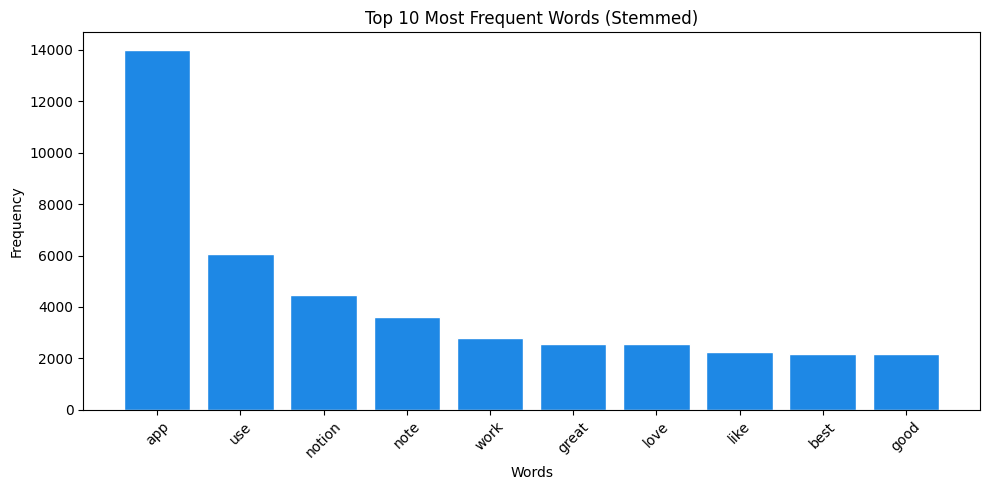

In [15]:
all_words = [word for tokens in df['stemmed_tokens'] for word in tokens]
word_freq = Counter(all_words)

freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency'])
freq_df = freq_df.sort_values(by='Frequency', ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    freq_df['Word'],
    freq_df['Frequency'],
    color='#1E88E5',
    edgecolor='white'
)

plt.title('Top 10 Most Frequent Words (Stemmed)')
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Rare Words Removal**

In [19]:
all_stemmed = [word for tokens in df['stemmed_tokens'] for word in tokens]
stemmed_freq = Counter(all_stemmed)

RARE_THRESHOLD = 2
rare_words = {w for w, f in stemmed_freq.items() if f <= RARE_THRESHOLD}

print(f"Unique words   : {len(stemmed_freq):,}")
print(f"Rare (freq<={RARE_THRESHOLD}) : {len(rare_words):,} "
      f"({len(rare_words)/len(stemmed_freq)*100:.1f}% of vocab)")
print(f"Sample rare    : {list(rare_words)[:15]}")

# remove rare words
df['final_tokens'] = df['stemmed_tokens'].apply(
    lambda t: [w for w in t if w not in rare_words]
)

before = df['stemmed_tokens'].apply(len).sum()
after = df['final_tokens'].apply(len).sum()

print(f"Tokens before : {before:,}")
print(f"Tokens after  : {after:,}")
print(f"Removed       : {before - after:,} ({(before-after)/before*100:.1f}%)")

df[['stemmed_tokens', 'final_tokens']].head()

Unique words   : 14,383
Rare (freq<=2) : 10,298 (71.6% of vocab)
Sample rare    : ['fox', 'tangan', 'decacorn', 'impecc', 'ludicr', 'wrongli', 'национальности', 'зовсім', 'timeli', 'мобильном', 'podrian', 'cacheclear', 'beliv', 'troublesom', 'внимание']
Tokens before : 272,127
Tokens after  : 260,185
Removed       : 11,942 (4.4%)


,stemmed_tokens,final_tokens
0,"[payment, issu, sav, solv, quickli]","[payment, issu, solv, quickli]"
1,"[use, notion, highend, phone, keep, get, laggi...","[use, notion, highend, phone, keep, get, laggi..."
2,"[love, app, document, keep, go, miss]","[love, app, document, keep, go, miss]"
3,"[power, new, ke, liy, itna, jada, hard, hai, u...","[power, new, ke, hard, hai, use, bad, ui, ux]"
4,"[bad, mobil, experi, everyth, slow, hard, actu...","[bad, mobil, experi, everyth, slow, hard, actu..."


### **Text Reconstruction**

In [20]:
# Reconstruct tokens into cleaned text
df['final_text'] = df['final_tokens'].apply(lambda tokens: " ".join(tokens))

# Check empty results after reconstruction
empty_count = df['final_text'].apply(lambda x: len(x.strip()) == 0).sum()

print(f"Empty texts after reconstruction: {empty_count:,}")

# Remove empty rows
df = df[df['final_text'].str.len() > 0]

print(f"Remaining dataset size: {len(df):,} rows")

Empty texts after reconstruction: 373
Remaining dataset size: 20,758 rows


/tmp/ipykernel_10906/2974765897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['final_word_count'] = df['final_tokens'].apply(len)


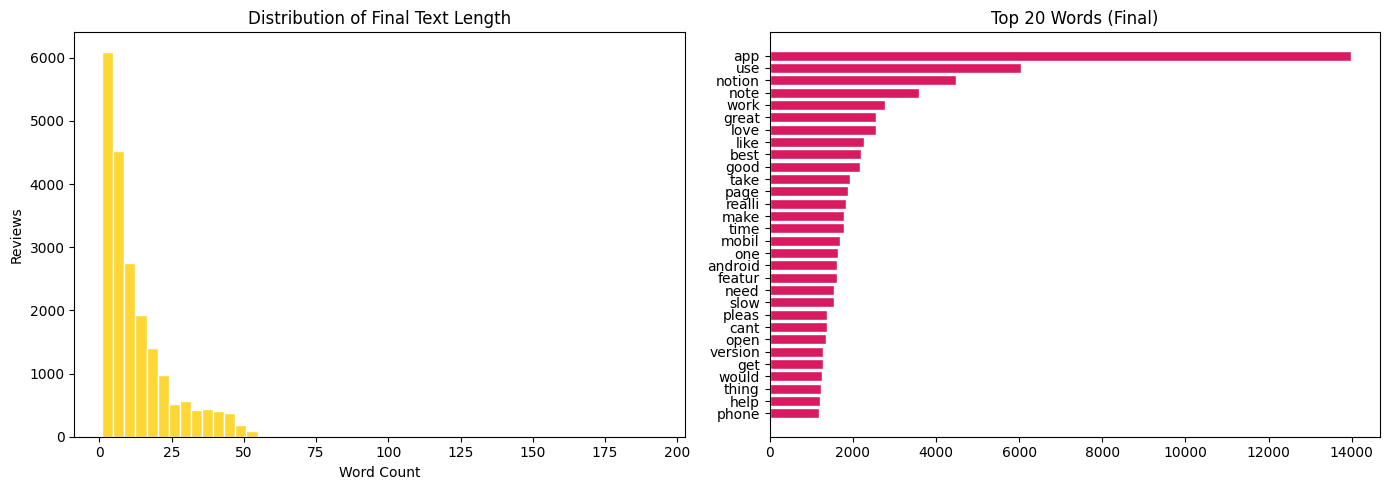

In [21]:
df['final_word_count'] = df['final_tokens'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(
    df['final_word_count'],
    bins=50,
    color='#FDD835',   # same style as your reference
    edgecolor='white'
)

axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Reviews')
axes[0].set_title('Distribution of Final Text Length')

# Top words
all_final = [w for tokens in df['final_tokens'] for w in tokens]
counter = Counter(all_final)

words, counts = zip(*counter.most_common(30))

axes[1].barh(
    range(30),
    counts,
    color='#D81B60',
    edgecolor='white'
)

axes[1].set_yticks(range(30))
axes[1].set_yticklabels(words)
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Words (Final)')

plt.tight_layout()
plt.show()

### **Data Export**

In [95]:
export_columns = [
    'content',
    'score',
    'at',
    'thumbsUpCount',
    'replyContent'
]

# optional columns (only add if exist)
optional_cols = ['sentiment', 'final_text', 'final_tokens']

for col in optional_cols:
    if col in df.columns:
        export_columns.append(col)

df_export = df.loc[:, export_columns].copy()

output_file = 'review_notion_clean.csv'
df_export.to_csv(output_file, index=False)

print(f"Dataset saved: {output_file}")
print(f"Shape: {df_export.shape[0]:,} rows × {df_export.shape[1]} columns")

df_export.head(5)

Dataset saved: review_notion_clean.csv
Shape: 20,758 rows × 7 columns


,content,score,at,thumbsUpCount,replyContent,final_text,final_tokens
0,"had a payment issue, the SAV solved it quickly.",5,2026-04-29 16:35:03,0,NaN,payment issu solv quickli,"[payment, issu, solv, quickli]"
1,"Using Notion on a high-end phone, but it keeps...",1,2026-04-29 14:15:07,0,NaN,use notion highend phone keep get laggier upda...,"[use, notion, highend, phone, keep, get, laggi..."
2,"I loved this app, but my documents keep going ...",3,2026-04-29 10:38:49,0,NaN,love app document keep go miss,"[love, app, document, keep, go, miss]"
3,powerful (All in 1). but new ke liye itna jada...,1,2026-04-29 09:22:59,0,NaN,power new ke hard hai use bad ui ux,"[power, new, ke, hard, hai, use, bad, ui, ux]"
4,Very bad mobile experience. Everything is so s...,1,2026-04-28 20:29:03,0,NaN,bad mobil experi everyth slow hard actual save...,"[bad, mobil, experi, everyth, slow, hard, actu..."
